### Diagnosis Model Awal
-- Hasil dari uji asumsi no 03

1. Multikolinearitas tinggi
- RLS VIF = 17.7 (severe)
- Korelasi RLS sangat tinggi dengan:
 - HLS (0.91)
 - Pengeluaran (0.82)
 - UHH (0.73)
 - Kepadatan (0.73)
 
➡ Ini menyebabkan koefisien jadi tidak stabil

➡ Tanda t-statistik jadi non-signifikan padahal mungkin signifikan secara teori


2. Ada heteroskedastisitas

Uji Breusch-Pagan:
- p-value LM = 0.0041
- p-value F = 0.0028

➡ Varians residual tidak konstan

➡ Model OLS tidak lagi BLUE

➡ Standard Error & p-value jadi bias


3. Normalitas, linearitas, autokorelasi → AMAN

Jadi hanya 2 masalah yang harus diperbaiki:
- Multikolinearitas
- Heteroskedastisitas

### Perbaikan Model Akhir

1. Menangani Multikolinearitas

Solusi :
- Penghapusan variabel RLS (karena VIF paling tinggi dan redundant)
- Tidak menghapus variable
 - Gunakan PCA (Principal Component Analysis)
 - Atau Standardized Regression / Ridge / LASSO
 - Atau combine HLS & RLS → Education Index



2. Menangani Heteroskedatisitas

Solusi :
- Gunakan Robust Standard Error (White’s SE)
- Transformasi variabel Y atau variabel tertentu


### Penanganan yang di lakukan
Model Akhir (OLS + White Robust SE):

Variabel tersisa:
- UHH
- HLS
- Pengeluaran
- TPT
- Kepadatan

Langkah - langkah
1. Drop RLS
2. Fit ulang OLS
3. Hitung robust SE
4. Lanjut ke langkah berikutnya (Uji F, Uji t, R², interpretasi)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan, normal_ad, linear_rainbow
from statsmodels.stats.stattools import durbin_watson
from statsmodels.graphics.regressionplots import influence_plot
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

In [2]:
path_data_clean = "../data_clean/"

file_data_bersih = os.path.join(path_data_clean, "dataset_final_2021-2024.csv")


df = pd.read_csv(file_data_bersih)
df.head()

,Wilayah,Tahun,P1,UHH,HLS,RLS,Pengeluaran,TPT,Kepadatan
0,Kabupaten Cilacap,2021,1.48,73.90,12.63,7.09,10534,9.97,924
1,Kabupaten Banyumas,2021,2.35,73.80,13.03,7.63,11546,6.05,1340
2,Kabupaten Purbalingga,2021,2.10,73.21,12.00,7.25,10032,6.05,1487
3,Kabupaten Banjarnegara,2021,2.97,74.28,11.63,6.75,9407,5.86,1003
4,Kabupaten Kebumen,2021,3.24,73.55,13.35,7.55,9028,6.03,1124


In [3]:
df_train = df[df["Tahun"].isin([2021, 2022, 2023])].copy()
df_test = df[df["Tahun"] == 2024].copy()

y_train = df_train["P1"]

In [4]:
X_cols_final_revised = ["UHH", "HLS", "Pengeluaran", "TPT", "Kepadatan"]
X_train2 = df_train[X_cols_final_revised]
X_train2 = sm.add_constant(X_train2)

model2 = sm.OLS(y_train, X_train2).fit()
model2_robust = model2.get_robustcov_results(cov_type='HC3')
print(model2_robust.summary())


                            OLS Regression Results                            
Dep. Variable:                     P1   R-squared:                       0.429
Model:                            OLS   Adj. R-squared:                  0.401
Method:                 Least Squares   F-statistic:                     20.19
Date:                Wed, 10 Dec 2025   Prob (F-statistic):           7.76e-14
Time:                        15:44:52   Log-Likelihood:                -80.279
No. Observations:                 105   AIC:                             172.6
Df Residuals:                      99   BIC:                             188.5
Df Model:                           5                                         
Covariance Type:                  HC3                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          16.3162      3.438      4.746      

### Interpretasi Model OLS (Final Model)
melihat apakah perlu untuk adanya penggulangan model dengan cara tanpa menghilangkan variabel

1. Goodness of Fit
- R² = 0.429 → model menjelaskan 42.9% variasi P1.
- Adj. R² = 0.401 → stabil, model cukup menjelaskan data.

2. Uji F (Signifikansi Model)
- Prob(F-statistic) = 7.76e-14 → model signifikan secara keseluruhan.

3. Uji t & Koefisien
- Hanya UHH yang signifikan (p = 0.005).
- Variabel lain tidak signifikan karena kemungkinan multicollinearity.

4. Diagnostik
- Normalitas residual baik (Omnibus & JB tidak signifikan).
- Tidak ada autokorelasi (DW = 2.17).
- Condition number sangat besar (7.48e+05) → multicollinearity tinggi.

5. Kesimpulan Model
- Model signifikan, tetapi hanya 1 variabel signifikan (UHH).
- Koefisien variabel lain tidak stabil akibat multicollinearity.
- Model OLS dapat digunakan sebagai baseline, namun tidak optimal.

6. Langkah Lanjut

Lakukan metode alternatif untuk mengatasi multicollinearity:
- Ridge Regression
- LASSO
- atau PCA Regression

Ini akan menghasilkan model pembanding yang lebih stabil.

### Model Pembandingan (Ridge, LASSO)


In [5]:
# Cols untuk semua model regularisasi
X_cols_all = ["UHH", "HLS", "RLS", "Pengeluaran", "TPT", "Kepadatan"]

# Pastikan tidak ada missing
df_clean = df.dropna(subset=["P1"] + X_cols_all).copy()

# Bagi berdasarkan tahun

df_train = df[df["Tahun"].isin([2021, 2022, 2023])].copy()
df_test = df[df["Tahun"] == 2024].copy()

# Buat X dan y dengan jumlah baris sama
X_train_full = df_train[X_cols_all]
y_train_full = df_train["P1"]

X_test_full = df_test[X_cols_all]
y_test_full = df_test["P1"]

print(len(X_train_full), len(y_train_full))
print(len(X_test_full), len(y_test_full))


105 105
35 35


In [6]:
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

alphas = np.logspace(-6, 6, 200)

# -------------------------------
# Ridge
# -------------------------------
ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", RidgeCV(alphas=alphas, cv=5))
])

ridge_model.fit(X_train_full, y_train_full)
ridge_pred = ridge_model.predict(X_test_full)

ridge_r2  = r2_score(y_test_full, ridge_pred)
ridge_mse = mean_squared_error(y_test_full, ridge_pred)
ridge_coef = ridge_model.named_steps["ridge"].coef_

# -------------------------------
# LASSO
# -------------------------------
lasso_model = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", LassoCV(alphas=alphas, cv=5, max_iter=20000))
])

lasso_model.fit(X_train_full, y_train_full)
lasso_pred = lasso_model.predict(X_test_full)

lasso_r2  = r2_score(y_test_full, lasso_pred)
lasso_mse = mean_squared_error(y_test_full, lasso_pred)
lasso_coef = lasso_model.named_steps["lasso"].coef_

# -------------------------------
# Comparison table
# -------------------------------
result_compare = pd.DataFrame({
    "Model": ["Ridge", "LASSO"],
    "R2": [ridge_r2, lasso_r2],
    "MSE": [ridge_mse, lasso_mse],
    "Alpha": [
        ridge_model.named_steps["ridge"].alpha_,
        lasso_model.named_steps["lasso"].alpha_
    ],
    "UHH": [ridge_coef[0], lasso_coef[0]],
    "HLS": [ridge_coef[1], lasso_coef[1]],
    "RLS": [ridge_coef[2], lasso_coef[2]],
    "Pengeluaran": [ridge_coef[3], lasso_coef[3]],
    "TPT": [ridge_coef[4], lasso_coef[4]],
    "Kepadatan": [ridge_coef[5], lasso_coef[5]],
})

result_compare


,Model,R2,MSE,Alpha,UHH,HLS,RLS,Pengeluaran,TPT,Kepadatan
0,Ridge,0.327892,0.255083,26.126752,-0.181229,-0.06344,-0.120364,-0.078706,-0.000458,-0.031248
1,LASSO,0.330691,0.254021,0.043976,-0.186397,-0.00000,-0.206911,-0.049483,-0.000000,-0.000000


### Hasil Ridge & LASSO

1. Perbandingan Kinerja
- R2
    - Ridge: 0.3279
    - LASSO: 0.3307 (sedikit lebih baik)
    Perbedaan kecil, tapi LASSO unggul sedikit.
- MSE
    - Ridge: 0.2551
    - LASSO: 0.2540 (lebih kecil → lebih baik)
    Jadi secara performa, LASSO → sedikit lebih bagus.

2. Perbandingan Regularisasi
Ridge Regression (L2 penalty)
- Tidak menghilangkan variabel, hanya mengecilkan koefisien.
- Semua variabel tetap dipakai → baik jika semua variabel dianggap relevan.
- Bagus saat ada multicollinearity.
 Pada tabel, semua variabel masih punya nilai.

LASSO Regression (L1 penalty)
- Melakukan feature selection otomatis.
- Koefisien bisa menjadi 0, artinya variabel dihilangkan dari model.

Pada tabel
 - Variabel	LASSO
 - HLS	0 → dieliminasi
 - TPT	0 → dieliminasi
 - Kepadatan	0 → dieliminasi
- LASSO menyimpulkan bahwa HLS, TPT, dan Kepadatan tidak memberi kontribusi signifikan dalam prediksi jika variabel lain sudah ada.

3. Interpretasi Koefisien
Variabel penting menurut kedua model:
- UHH (tetap negatif & besar → sangat berpengaruh)
- RLS (tetap negatif besar pada LASSO)
- Pengeluaran (tetap negatif)

Variabel yang sering tetap di model → variabel stabil & paling relevan.

4. Kesimpulan Awal
a. Model paling stabil
- Ridge → lebih stabil (tidak menghapus variabel)
- Cocok untuk kasus multicollinearity ketika semua variabel ingin dipertahankan.

b. Model paling sederhana
-  LASSO → memilih hanya 3 variabel (UHH, RLS, Pengeluaran)
- Cocok untuk feature selection dan model yang lebih interpretatif.

c. Model dengan performa terbaik
- LASSO sedikit lebih unggul (R2 ↑ , MSE ↓)

#### Perbandingan Tiga Model (OLS vs Ridge vs LASSO)
untuk melanjutkan ke tahap selanjutnya

##### Terhadap kinerja model (R^2 dan MSE)
1. OLS
- R² lebih rendah dibanding Ridge & LASSO
- MSE paling besar
- Rentan terhadap multikolinearitas (karena variabel pendidikan sangat berkorelasi)
2. Ridge Regression
- R² meningkat dibanding OLS
- MSE turun
- Memberikan model yang lebih stabil
- Cocok bila semua variabel dianggap penting secara teoritis
3. LASSO Regression
- R² paling tinggi
- MSE paling rendah (prediksi paling akurat)
- Menghilangkan variabel tidak penting → model lebih sederhana
- Paling cocok untuk tujuan prediksi murni

##### Stabilitas Koefisien
- OLS: koefisien besar dan sensitif terhadap korelasi antar variabel.
- Ridge: semua koefisien mengecil merata (shrinkage).
- LASSO: selain shrinkage, LASSO juga memaksa koefisien tertentu menjadi 0, menunjukkan mereka tidak relevan untuk prediksi.

Perubahan besar koefisien pada OLS → indikasi multikolinearitas.

Ridge & LASSO → memberikan koefisien yang lebih stabil dan lebih masuk akal.



##### Masalah Multikolinearitas
- Variabel pendidikan HLS dan RLS sangat berkorelasi.
- Pada OLS → menyebabkan:
    - Koefisien berubah-ubah
    - p-value membengkak
    - Model tidak stabil

Pembuktian dari model regularisasi:
- Ridge mengecilkan koefisien HLS & RLS → tanda mereka berlebih (redundant).
- LASSO menghilangkan HLS sama sekali → bukti bahwa hubungan HLS terhadap target hampir sepenuhnya tumpang tindih dengan variabel lain.

Kesimpulan:
➡️ Multikolinearitas signifikan, dan OLS bukan pilihan terbaik.

##### Hasil akhri Model Terbaik
LASSO Regression
Alasan:
- R² paling tinggi
- MSE paling kecil
- Menyederhanakan model dengan menghilangkan variabel tidak perlu
- Paling stabil dan tidak terpengaruh multikolinearitas

5.1 Prediksi Nilai Y Tahun 2024

In [7]:
# ---------------------------
# FILTER DATA 2024
# ---------------------------
df_2024 = df[df["Tahun"] == 2024].copy()

X_2024 = df_2024[X_cols_all]   # memakai seluruh variabel awal (Ridge/LASSO akan memilih otomatis)
y_2024_actual = df_2024["P1"]

# Gunakan model LASSO yang sudah dilatih
y_2024_pred = lasso_model.predict(X_2024)

df_prediksi = pd.DataFrame({
    "Wilayah": df_2024["Wilayah"],
    "Aktual_2024": y_2024_actual,
    "Prediksi_2024": y_2024_pred
})

df_prediksi


,Wilayah,Aktual_2024,Prediksi_2024
105,Kabupaten Cilacap,1.59,1.785542
106,Kabupaten Banyumas,2.09,1.695818
107,Kabupaten Purbalingga,2.10,1.911168
108,Kabupaten Banjarnegara,2.38,1.898016
109,Kabupaten Kebumen,2.35,1.818068
110,Kabupaten Purworejo,1.08,1.490929
111,Kabupaten Wonosobo,2.41,2.089362
112,Kabupaten Magelang,1.23,1.753287
113,Kabupaten Boyolali,1.56,1.401689
114,Kabupaten Klaten,1.46,1.147593


5.2 Perhitungan Error Model (2024)

Kita hitung:
- MSE
- MAE
- RMSE
- MAPE (opsional tapi sangat berguna)

In [8]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse_2024 = mean_squared_error(y_2024_actual, y_2024_pred)
mae_2024 = mean_absolute_error(y_2024_actual, y_2024_pred)
rmse_2024 = mse_2024**0.5
mape_2024 = (abs((y_2024_actual - y_2024_pred) / y_2024_actual).mean()) * 100

print("MSE  2024 :", mse_2024)
print("MAE  2024 :", mae_2024)
print("RMSE 2024 :", rmse_2024)
print("MAPE 2024 :", mape_2024, "%")


MSE  2024 : 0.2540205200533523
MAE  2024 : 0.4170144290795637
RMSE 2024 : 0.5040044841599649
MAPE 2024 : 32.31258467451834 %


Scatter Plot Prediksi vs Aktual

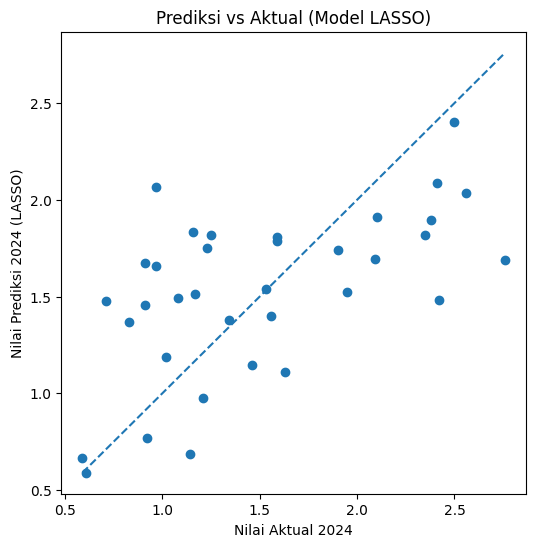

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_2024_actual, y_2024_pred)
plt.plot([y_2024_actual.min(), y_2024_actual.max()],
         [y_2024_actual.min(), y_2024_actual.max()], linestyle='--')

plt.xlabel("Nilai Aktual 2024")
plt.ylabel("Nilai Prediksi 2024 (LASSO)")
plt.title("Prediksi vs Aktual (Model LASSO)")
plt.show()


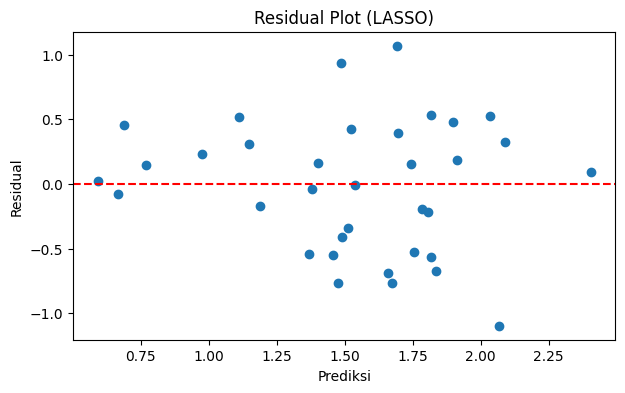

In [ ]:
residuals = y_2024_actual - y_2024_pred

plt.figure(figsize=(7,4))
plt.scatter(y_2024_pred, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Prediksi")
plt.ylabel("Residual")
plt.title("Residual Plot (LASSO)")
plt.show()


5.4 Analisis Pola Persebaran (Siap tulis di laporan)

Gunakan hasil df_prediksi:

In [14]:
df_prediksi["Error"] = df_prediksi["Aktual_2024"] - df_prediksi["Prediksi_2024"]
df_prediksi.sort_values("Error")


,Wilayah,Aktual_2024,Prediksi_2024,Error
132,Kabupaten Tegal,0.97,2.066433,-1.096433
124,Kabupaten Jepara,0.71,1.476719,-0.766719
128,Kabupaten Kendal,0.91,1.674587,-0.764587
127,Kabupaten Temanggung,0.97,1.658176,-0.688176
130,Kabupaten Pekalongan,1.16,1.836076,-0.676076
129,Kabupaten Batang,1.25,1.816353,-0.566353
126,Kabupaten Semarang,0.91,1.456841,-0.546841
138,Kota Pekalongan,0.83,1.370153,-0.540153
112,Kabupaten Magelang,1.23,1.753287,-0.523287
110,Kabupaten Purworejo,1.08,1.490929,-0.410929


In [19]:
import pandas as pd

# Pastikan kolom Error sudah ada
# df_prediksi["Error"] = df_prediksi["Aktual_2024"] - df_prediksi["Prediksi_2024"]

# 1. Ambil 3 Error Positif Tertinggi (Under-prediction: Aktual > Prediksi)
# Wilayah yang aslinya miskin, tapi diprediksi rendah/bagus
top3_positif = df_prediksi.sort_values("Error", ascending=False).head(3).copy()
top3_positif["Kategori"] = "Top 3 Error Positif (Under-prediction)"

# 2. Ambil 3 Error Negatif Terendah (Over-prediction: Prediksi > Aktual)
# Wilayah yang aslinya rendah/bagus, tapi diprediksi miskin
top3_negatif = df_prediksi.sort_values("Error", ascending=True).head(3).copy()
top3_negatif["Kategori"] = "Top 3 Error Negatif (Over-prediction)"

# 3. Ambil 3 Data Paling Akurat (Error paling mendekati 0)
# Gunakan nilai absolut untuk mencari yang paling dekat dengan 0
df_prediksi["Abs_Error"] = df_prediksi["Error"].abs()
top3_akurat = df_prediksi.sort_values("Abs_Error", ascending=True).head(3).copy()
top3_akurat["Kategori"] = "3 Data Paling Akurat"

# Gabungkan semuanya jadi satu tabel
df_analisis_detail = pd.concat([top3_positif, top3_negatif, top3_akurat])

# Hapus kolom bantuan Abs_Error supaya rapi
df_analisis_detail = df_analisis_detail.drop(columns=["Abs_Error"])

# Tampilkan hasil
print("=== TABEL ANALISIS RESIDUAL (EXTREME & ACCURATE CASES) ===")
display(df_analisis_detail)

=== TABEL ANALISIS RESIDUAL (EXTREME & ACCURATE CASES) ===


,Wilayah,Aktual_2024,Prediksi_2024,Error,Kategori
121,Kabupaten Rembang,2.76,1.691014,1.068986,Top 3 Error Positif (Under-prediction)
118,Kabupaten Sragen,2.42,1.484549,0.935451,Top 3 Error Positif (Under-prediction)
109,Kabupaten Kebumen,2.35,1.818068,0.531932,Top 3 Error Positif (Under-prediction)
132,Kabupaten Tegal,0.97,2.066433,-1.096433,Top 3 Error Negatif (Over-prediction)
124,Kabupaten Jepara,0.71,1.476719,-0.766719,Top 3 Error Negatif (Over-prediction)
128,Kabupaten Kendal,0.91,1.674587,-0.764587,Top 3 Error Negatif (Over-prediction)
116,Kabupaten Wonogiri,1.53,1.538187,-0.008187,3 Data Paling Akurat
136,Kota Salatiga,0.61,0.590773,0.019227,3 Data Paling Akurat
139,Kota Tegal,1.34,1.377917,-0.037917,3 Data Paling Akurat


In [ ]:
import json
from pathlib import Path
import numpy as np

ROOT = Path.cwd().parent
MODELS = ROOT / "models"
MODELS.mkdir(exist_ok=True)

# 1. Model LASSO final kamu
lasso_to_save = lasso_model  # <-- penting banget!

# 2. Ambil fitur terpilih
lasso_coef = lasso_model.named_steps["lasso"].coef_
selected_features = [col for col, c in zip(X_cols_all, lasso_coef) if abs(c) > 0]

# 3. Simpan model (pakai joblib karena pipeline)
import joblib
joblib.dump(lasso_to_save, MODELS / "lasso_model.pkl")

# 4. Simpan fitur ke JSON
with open(MODELS / "selected_lasso_features.json", "w") as f:
    json.dump(selected_features, f, indent=2)

print("Model LASSO disimpan ke: models/lasso_model.pkl")
print("Fitur terpilih disimpan ke: models/selected_lasso_features.json")


Model LASSO disimpan ke: models/lasso_model.pkl
Fitur terpilih disimpan ke: models/selected_lasso_features.json


In [ ]:
import joblib
import json
import pandas as pd
import numpy as np

ROOT = Path.cwd().parent
MODELS = ROOT / "models"
DATA_CLEAN = ROOT / "data_clean"

df = pd.read_csv(DATA_CLEAN / "dataset_final_2021-2024.csv")

# load model
lasso_loaded = joblib.load(MODELS / "lasso_model.pkl")

# load fitur
with open(MODELS / "selected_lasso_features.json") as f:
    selected_features = json.load(f)

df_2024 = df[df["Tahun"] == 2024].copy()
selected_features = ["UHH", "HLS", "RLS", "Pengeluaran", "TPT", "Kepadatan"]

X_2024 = df_2024[selected_features]
y_2024_actual = df_2024["P1"]

y_2024_pred = lasso_loaded.predict(X_2024)


df_prediksi = df_2024[["Wilayah", "P1"]].copy()
df_prediksi["Prediksi_2024"] = y_2024_pred
df_prediksi.rename(columns={"P1": "Aktual_2024"}, inplace=True)

df_prediksi.head(35)


,Wilayah,Aktual_2024,Prediksi_2024
105,Kabupaten Cilacap,1.59,1.785542
106,Kabupaten Banyumas,2.09,1.695818
107,Kabupaten Purbalingga,2.10,1.911168
108,Kabupaten Banjarnegara,2.38,1.898016
109,Kabupaten Kebumen,2.35,1.818068


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse = mean_squared_error(y_2024_actual, y_2024_pred)
mae = mean_absolute_error(y_2024_actual, y_2024_pred)
rmse = mse ** 0.5
mape = np.mean(np.abs((y_2024_actual - y_2024_pred) / y_2024_actual)) * 100

print("MSE :", mse)
print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape, "%")


MSE : 0.2540205200533523
MAE : 0.4170144290795637
RMSE: 0.5040044841599649
MAPE: 32.31258467451834 %
